Generador del Dataset

In [1]:
import pandas as pd
import numpy as np
np.random.seed(42)
cantidad = 1500
categorias = np.random.choice(['Electronica', 'Indumentaria', 'Hogar', 'Ferreteria'], cantidad)
turnos = np.random.choice(['Mañana', 'Tarde', 'Noche'], cantidad)
tiempos = np.random.normal(45, 15, cantidad)
montos = np.random.normal(25000, 8000, cantidad)
df_ventas = pd.DataFrame({
    'ID_Transaccion': np.arange(10000, 10000 + cantidad),
    'Categoria': categorias,
    'Turno_Entrega': turnos,
    'Tiempo_Despacho_Min': tiempos,
    'Monto_ARS': montos
})
indices_ruido = np.random.choice(df_ventas.index, 80, replace=False)
df_ventas.loc[indices_ruido[:20], 'Tiempo_Despacho_Min'] = np.random.uniform(300, 800, 20)
df_ventas.loc[indices_ruido[20:40], 'Tiempo_Despacho_Min'] = np.random.uniform(-100, -10, 20)
df_ventas.loc[indices_ruido[40:60], 'Monto_ARS'] = np.random.uniform(5000000, 9000000, 20)
df_ventas.loc[indices_ruido[60:], 'Monto_ARS'] = np.random.uniform(-5000, -500, 20)
df_ventas = df_ventas.sample(frac=1).reset_index(drop=True)
df_ventas.to_csv('logistica_cuyo_auditoria.csv', index=False)
print('Dataset logistica_cuyo_auditoria.csv generado.')

Dataset logistica_cuyo_auditoria.csv generado.


Fase 1

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('logistica_cuyo_auditoria.csv')
sns.set_theme(style="darkgrid")

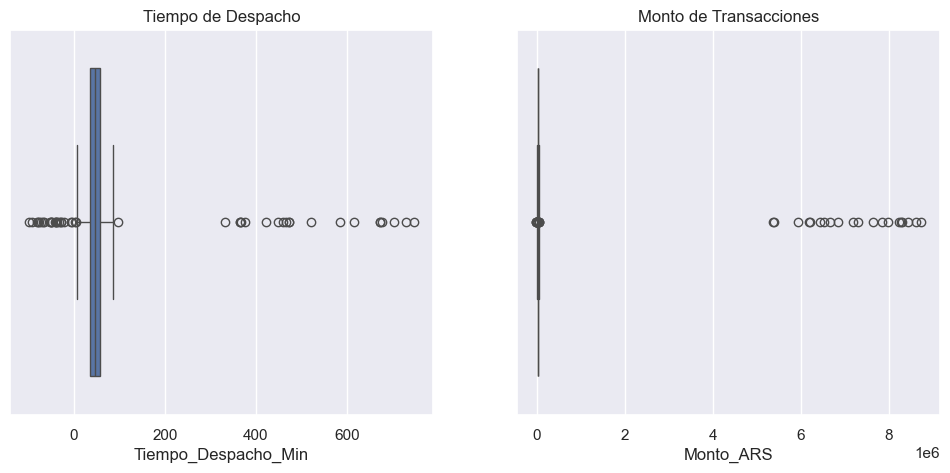

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=df,
    x="Tiempo_Despacho_Min",
    ax=axes[0]
)

axes[0].set_title("Tiempo de Despacho")

sns.boxplot(
    data=df,
    x="Monto_ARS",
    ax=axes[1]
)

axes[1].set_title("Monto de Transacciones")

plt.show()

Fase 2

In [5]:
Q1_tiempo = df["Tiempo_Despacho_Min"].quantile(0.25)
Q3_tiempo = df["Tiempo_Despacho_Min"].quantile(0.75)

IQR_tiempo = Q3_tiempo - Q1_tiempo

lim_inf_tiempo = Q1_tiempo - 1.5 * IQR_tiempo
lim_sup_tiempo = Q3_tiempo + 1.5 * IQR_tiempo

In [6]:
mascara_tiempo = (
    (df["Tiempo_Despacho_Min"] >= lim_inf_tiempo)
    &
    (df["Tiempo_Despacho_Min"] <= lim_sup_tiempo)
)

In [8]:
Q1_monto = df["Monto_ARS"].quantile(0.25)
Q3_monto = df["Monto_ARS"].quantile(0.75)

IQR_monto = Q3_monto - Q1_monto

lim_inf_monto = Q1_monto - 1.5 * IQR_monto
lim_sup_monto = Q3_monto + 1.5 * IQR_monto

In [9]:
mascara_monto = (
    (df["Monto_ARS"] >= lim_inf_monto)
    &
    (df["Monto_ARS"] <= lim_sup_monto)
)

In [10]:
df_limpio = df[
    mascara_tiempo
    &
    mascara_monto
]

In [11]:
print("Filas originales:", len(df))
print("Filas limpias:", len(df_limpio))

print(
    "Registros eliminados:",
    len(df) - len(df_limpio)
)

Filas originales: 1500
Filas limpias: 1412
Registros eliminados: 88


Fase 3

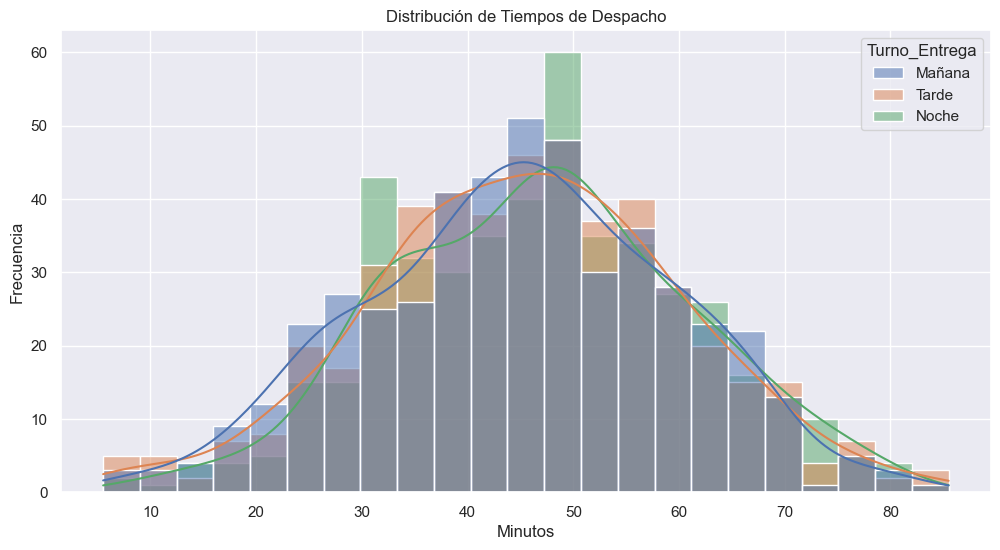

In [12]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df_limpio,
    x="Tiempo_Despacho_Min",
    hue="Turno_Entrega",
    kde=True
)

plt.title("Distribución de Tiempos de Despacho")
plt.xlabel("Minutos")
plt.ylabel("Frecuencia")

plt.show()

Analizando la superposición de las campanas en el gráfico, respondan mediante un print(): ¿Existe
algún turno que sea significativamente más lento que los demás, o todos tienen una distribución
similar?


In [14]:
print("Las distribuciones de los tres turnos presentan formas similares.No se observa un turno significativamente más lento que los demás.Las diferencias visuales parecen responder a variaciones normales del muestreo y no a un problema operativo específico.")

Las distribuciones de los tres turnos presentan formas similares.No se observa un turno significativamente más lento que los demás.Las diferencias visuales parecen responder a variaciones normales del muestreo y no a un problema operativo específico.


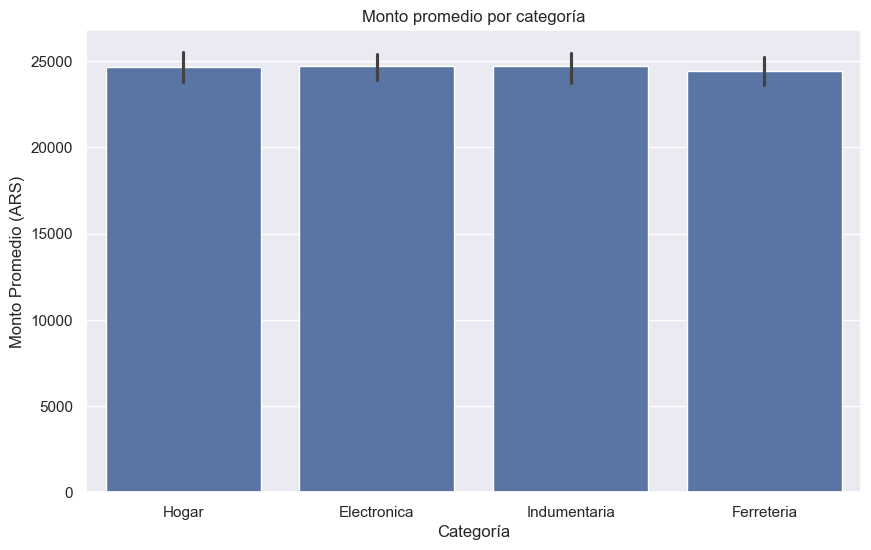

In [13]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_limpio,
    x="Categoria",
    y="Monto_ARS"
)

plt.title("Monto promedio por categoría")
plt.xlabel("Categoría")
plt.ylabel("Monto Promedio (ARS)")

plt.show()